# LOST Object-Discovery — Discovery Experiment

Qualitative reproduction of Section 3.3 of *Vision Transformers Need Registers* (Darcet et al., ICLR 2024, [arXiv:2309.16588](https://arxiv.org/abs/2309.16588)).


## 1. Dependencies

Auto-install any missing packages.

In [1]:
import importlib, subprocess, sys

_REQUIRED = {
    "torch": "torch",
    "torchvision": "torchvision",
    "numpy": "numpy",
    "PIL": "Pillow",
    "matplotlib": "matplotlib",
    "requests": "requests",
}

for module_name, pip_name in _REQUIRED.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

print("Dependencies OK.")

Dependencies OK.


## 2. Imports and setup

In [2]:
import io
import os
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image

torch.manual_seed(0)
np.random.seed(0)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
print(f"Using device: {DEVICE}")

Using device: cpu


## 3. Load DINOv2 (with and without registers)

ViT-L/14 from `torch.hub`. Both variants share the same architecture; the `_reg` one has 4 extra register tokens that are stripped from the returned patch tensor. First run downloads ~1.1 GB × 2 (cached afterwards).

In [3]:
MODEL_SIZE = "l"  # per paper Fig. 4c, outliers appear only at ViT-L and above.
                  # Use 'b' (87M) or 's' (22M) for a faster but less dramatic demo.

def load_dinov2(with_registers: bool):
    """Load a DINOv2 ViT-{MODEL_SIZE}/14 with or without registers from torch.hub."""
    name = f"dinov2_vit{MODEL_SIZE}14" + ("_reg" if with_registers else "")
    model = torch.hub.load("facebookresearch/dinov2", name, trust_repo=True)
    return model.eval().to(DEVICE)

model_plain = load_dinov2(with_registers=False)
model_reg   = load_dinov2(with_registers=True)

PATCH = 14  # DINOv2 patch size
EMBED_DIM = model_plain.embed_dim
N_REGISTERS = getattr(model_reg, "num_register_tokens", 4)

print(f"Loaded DINOv2 ViT-{MODEL_SIZE.upper()}/14")
print(f"  embed_dim: {EMBED_DIM}")
print(f"  registers (in the _reg variant): {N_REGISTERS}")

Using cache found in /Users/paolodeidda/.cache/torch/hub/facebookresearch_dinov2_main
/Users/paolodeidda/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/paolodeidda/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/paolodeidda/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Using cache found in /Users/paolodeidda/.cache/torch/hub/facebookresearch_dinov2_main


Loaded DINOv2 ViT-L/14
  embed_dim: 1024
  registers (in the _reg variant): 4


## 4. Sample images

Three natural images from stable github-raw URLs, with a synthetic fallback if offline.

  dog.jpg: (1546, 1213)
  cat.jpg: (335, 500)
  bird.jpg: (400, 500)


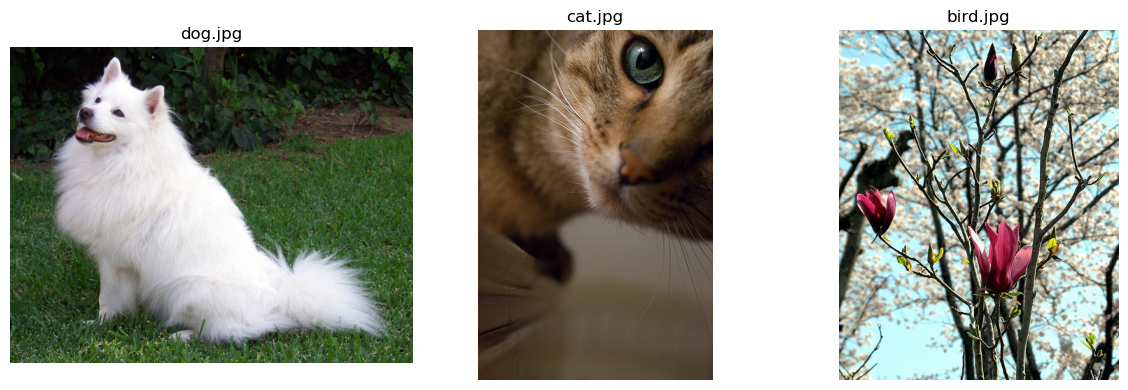

In [4]:
IMG_DIR = Path("images")
IMG_DIR.mkdir(exist_ok=True)

SAMPLE_URLS = [
    # Stable github-raw URLs (no rate limits).
    ("dog.jpg",    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"),
    ("cat.jpg",    "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123045_tabby.JPEG"),
    ("bird.jpg",   "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01608432_kite.JPEG"),
]

def make_synthetic_image(seed: int = 0) -> Image.Image:
    """Offline fallback: a coloured disk (the 'object') on a mildly-textured background."""
    rng = np.random.default_rng(seed)
    H = W = 256
    bg = rng.integers(80, 170, size=(H, W, 3), dtype=np.uint8)
    yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    mask = ((yy - H // 2) ** 2 + (xx - W // 2) ** 2) < (H // 5) ** 2
    bg[mask] = [220, 80, 50]
    return Image.fromarray(bg)

def fetch_image(name: str, url: str, timeout: float = 10.0) -> Image.Image:
    path = IMG_DIR / name
    if not path.exists():
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=timeout) as r:
                path.write_bytes(r.read())
        except Exception as e:
            print(f"  [warn] download of {name} failed ({e}); using synthetic fallback.")
            return make_synthetic_image(seed=hash(name) % (2**32))
    return Image.open(path).convert("RGB")

images = []
for name, url in SAMPLE_URLS:
    img = fetch_image(name, url)
    images.append((name, img))
    print(f"  {name}: {img.size}")

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
if len(images) == 1:
    axes = [axes]
for ax, (name, img) in zip(axes, images):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Preprocessing

ImageNet stats, 224×224 → 16×16 patch grid. Drop `IMG_SIZE` if too slow; raise it for richer maps.

In [5]:
IMG_SIZE = 224  # multiple of PATCH = 14 (drop from 448 to keep ViT-L CPU runtime reasonable)
GRID = IMG_SIZE // PATCH  # number of patches per side
N_PATCHES = GRID * GRID
print(f"Input {IMG_SIZE}x{IMG_SIZE}  ->  {GRID}x{GRID} = {N_PATCHES} patch tokens")

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

preprocess = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

Input 224x224  ->  16x16 = 256 patch tokens


## 6. Feature extraction

Return **pre-norm** patch tokens (for the outlier story — post-LN collapses norms) and **post-norm** patch tokens (for LOST — smoother cosine graph).

In [6]:
@torch.no_grad()
def get_patch_tokens(model, pil_img):
    """Return (patch_tokens_prenorm, patch_tokens_postnorm, cls_token) for a single PIL image.

    The paper's outlier norms are measured BEFORE the final LayerNorm — that's
    exposed as 'x_prenorm' in the DINOv2 hub API. Post-LN norms are compressed
    to ~sqrt(D), which hides the effect. We return both:
      - prenorm patches: used for the norm-map visualisation (outlier story).
      - postnorm patches: smoother, used for LOST similarity.
    """
    x = preprocess(pil_img).unsqueeze(0).to(DEVICE)
    out = model.forward_features(x)
    n_regs = getattr(model, "num_register_tokens", 0)
    n_special = 1 + n_regs  # [CLS] + registers
    patch_pre  = out["x_prenorm"][0, n_special:].cpu()
    patch_post = out["x_norm_patchtokens"][0].cpu()
    cls_token  = out["x_norm_clstoken"][0].cpu()
    return patch_pre, patch_post, cls_token


## 7. Norm-map visualisation

Pre-norm patch-token L2 norms, reshaped onto the patch grid, on a shared colour scale. Expect sparse bright outliers in no-reg and a smoother map in with-reg.

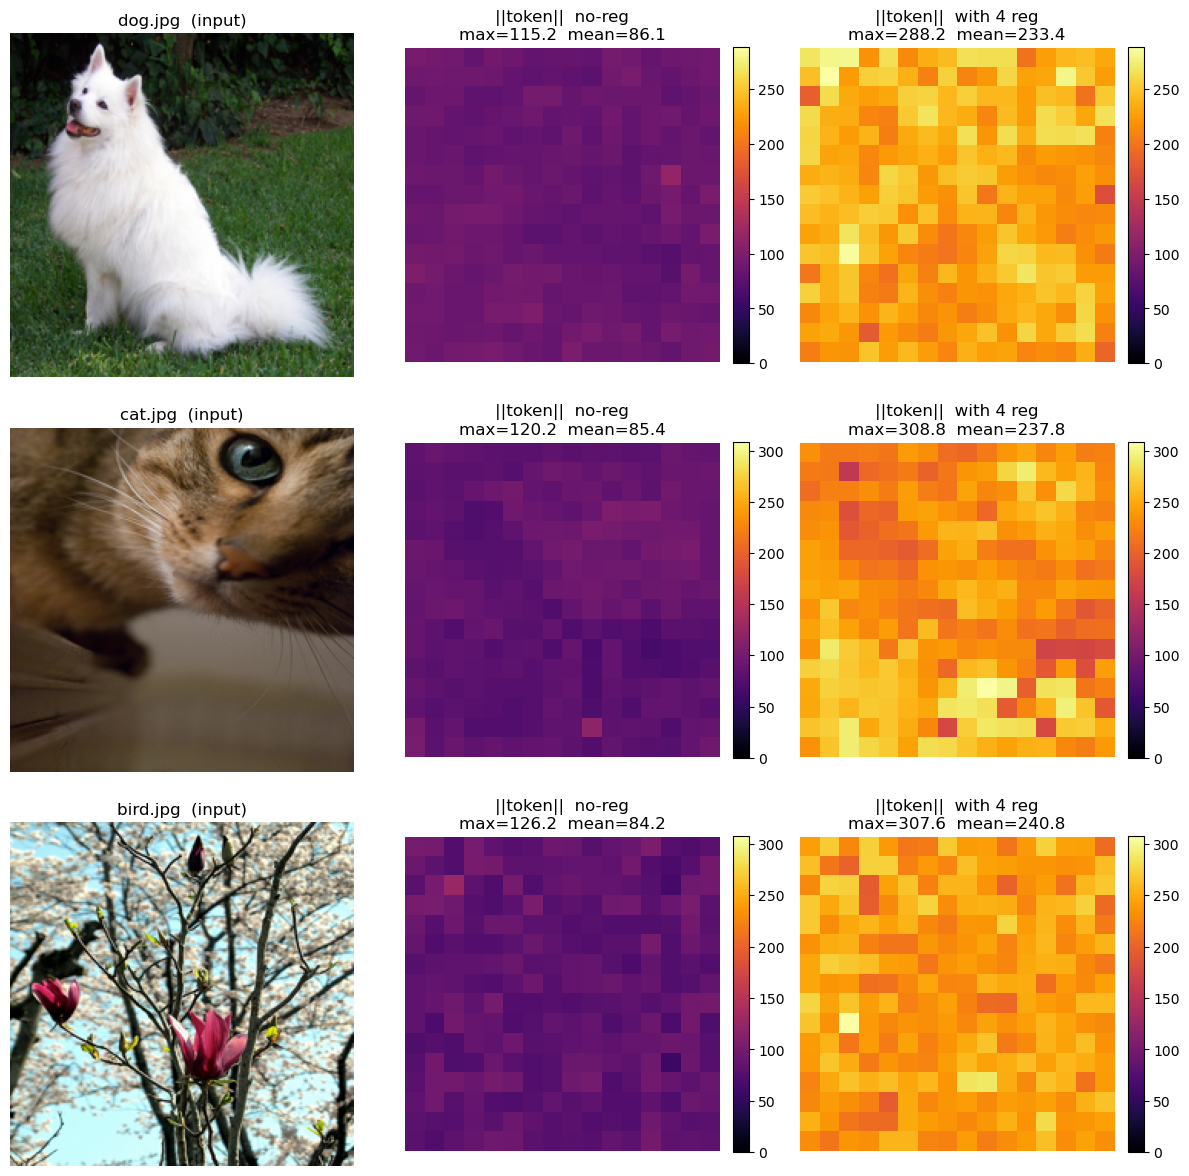

In [7]:
def norm_map(patch_tokens):
    """(N_patches, D) -> (GRID, GRID) numpy array of L2 norms."""
    norms = patch_tokens.norm(dim=-1)
    return norms.view(GRID, GRID).numpy()

def show_norm_comparison(images):
    fig, axes = plt.subplots(len(images), 3, figsize=(12, 4 * len(images)))
    if len(images) == 1:
        axes = axes[None, :]
    for row, (name, img) in enumerate(images):
        toks_plain, _, _ = get_patch_tokens(model_plain, img)
        toks_reg,   _, _ = get_patch_tokens(model_reg,   img)
        m_plain = norm_map(toks_plain)
        m_reg   = norm_map(toks_reg)
        vmax = max(m_plain.max(), m_reg.max())

        axes[row, 0].imshow(img.resize((IMG_SIZE, IMG_SIZE)))
        axes[row, 0].set_title(f"{name}  (input)")
        axes[row, 0].axis("off")

        im1 = axes[row, 1].imshow(m_plain, cmap="inferno", vmin=0, vmax=vmax)
        axes[row, 1].set_title(
            f"||token||  no-reg\nmax={m_plain.max():.1f}  mean={m_plain.mean():.1f}"
        )
        axes[row, 1].axis("off")
        plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

        im2 = axes[row, 2].imshow(m_reg, cmap="inferno", vmin=0, vmax=vmax)
        axes[row, 2].set_title(
            f"||token||  with 4 reg\nmax={m_reg.max():.1f}  mean={m_reg.mean():.1f}"
        )
        axes[row, 2].axis("off")
        plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

show_norm_comparison(images)

Bright spots in the no-reg column land in low-information areas (the model's "scratchpad"). The with-reg column is smoother because that computation now lives in the register tokens — see [`README.md`](README.md).

## 8. Simplified LOST

Cosine gram → lowest-degree seed → seed-expansion score. Full formulation and motivation in [`README.md`](README.md).

In [ ]:
def lost(patch_tokens, k_seed_expansion: int = 100):
    """Simplified LOST. Returns (seed_idx, seed_sim_map, expansion_map).

    - seed_sim_map:  the raw similarity of every patch to the seed (GRID x GRID).
    - expansion_map: the seed-expansion score (GRID x GRID).
    """
    feats = patch_tokens / patch_tokens.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    S = feats @ feats.T                           # (N, N)
    A = (S > 0).float()
    degrees = A.sum(dim=-1)
    seed = int(torch.argmin(degrees).item())

    seed_sim = S[seed]                             # (N,)
    topk = torch.topk(seed_sim, k=k_seed_expansion).indices
    expansion = S[topk].sum(dim=0)                 # (N,)

    return (
        seed,
        seed_sim.view(GRID, GRID).numpy(),
        expansion.view(GRID, GRID).numpy(),
    )

## 9. Side-by-side comparison

For each image: input · norm no-reg · LOST no-reg · norm reg · LOST reg. Red ⋆ = seed patch.

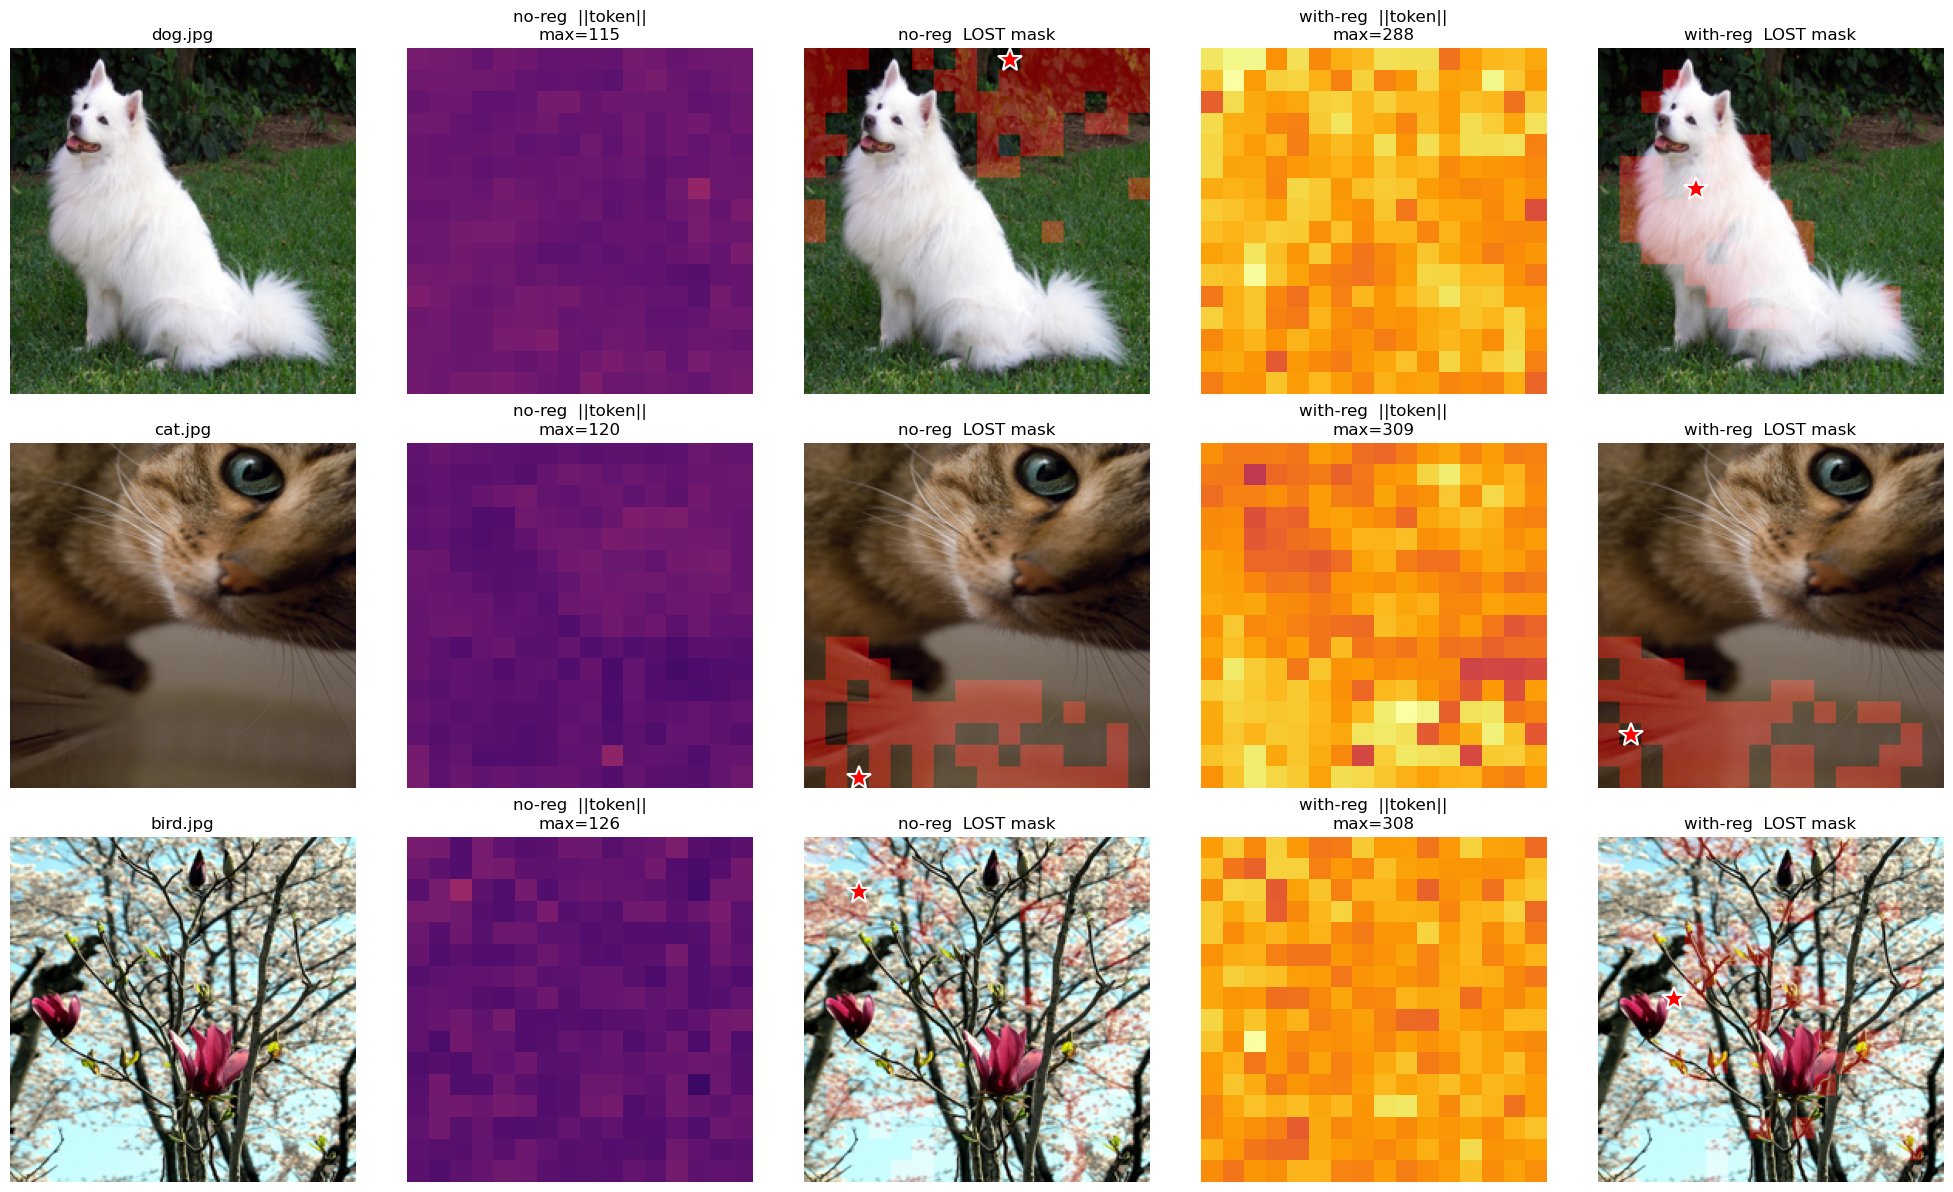

In [9]:
def run_and_plot(images, threshold_quantile: float = 0.80):
    """For each image, run LOST on both models and plot the full strip."""
    n = len(images)
    fig, axes = plt.subplots(n, 5, figsize=(20, 4 * n))
    if n == 1:
        axes = axes[None, :]

    for row, (name, img) in enumerate(images):
        pre_p, post_p, _ = get_patch_tokens(model_plain, img)
        pre_r, post_r, _ = get_patch_tokens(model_reg,   img)

        # LOST runs on post-norm (smoother); norm maps on pre-norm (shows outliers).
        seed_p, _, expansion_p = lost(post_p)
        seed_r, _, expansion_r = lost(post_r)

        m_plain = norm_map(pre_p)
        m_reg   = norm_map(pre_r)
        vmax_norm = max(m_plain.max(), m_reg.max())

        # Binary LOST mask: top-(1-q) quantile of the expansion score.
        def to_mask(m):
            thr = np.quantile(m, threshold_quantile)
            return m > thr

        # Col 0: input
        axes[row, 0].imshow(img.resize((IMG_SIZE, IMG_SIZE)))
        axes[row, 0].set_title(f"{name}")
        axes[row, 0].axis("off")

        # Col 1 / 3: norm maps (shared scale)
        axes[row, 1].imshow(m_plain, cmap="inferno", vmin=0, vmax=vmax_norm)
        axes[row, 1].set_title(f"no-reg  ||token||\nmax={m_plain.max():.0f}")
        axes[row, 1].axis("off")

        axes[row, 3].imshow(m_reg, cmap="inferno", vmin=0, vmax=vmax_norm)
        axes[row, 3].set_title(f"with-reg  ||token||\nmax={m_reg.max():.0f}")
        axes[row, 3].axis("off")

        # Col 2 / 4: LOST mask overlaid on the image
        for col, mask_img, seed_idx, subtitle in [
            (2, to_mask(expansion_p), seed_p, "no-reg  LOST mask"),
            (4, to_mask(expansion_r), seed_r, "with-reg  LOST mask"),
        ]:
            upsampled = np.kron(mask_img.astype(float), np.ones((PATCH, PATCH)))
            base = np.asarray(img.resize((IMG_SIZE, IMG_SIZE))).astype(float) / 255.0
            overlay = base.copy()
            overlay[..., 0] = np.where(upsampled > 0, 1.0, overlay[..., 0])
            overlay = 0.55 * base + 0.45 * overlay
            axes[row, col].imshow(np.clip(overlay, 0, 1))
            seed_y, seed_x = seed_idx // GRID, seed_idx % GRID
            axes[row, col].plot((seed_x + 0.5) * PATCH, (seed_y + 0.5) * PATCH,
                                marker="*", color="red", markersize=18,
                                markeredgecolor="white", markeredgewidth=1.5)
            axes[row, col].set_title(subtitle)
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

run_and_plot(images)

## 10. Quantitative sanity checks

max/mean ratio and %-of-tokens above 1.5×median, pooled over all sample images.

metric                      mean      median         max    max/mean     %>213.4
--------------------------------------------------------------------------------
no-reg                     85.26       84.61      126.22        1.48        0.00
with-reg                  237.35      236.74      308.80        1.30       86.85


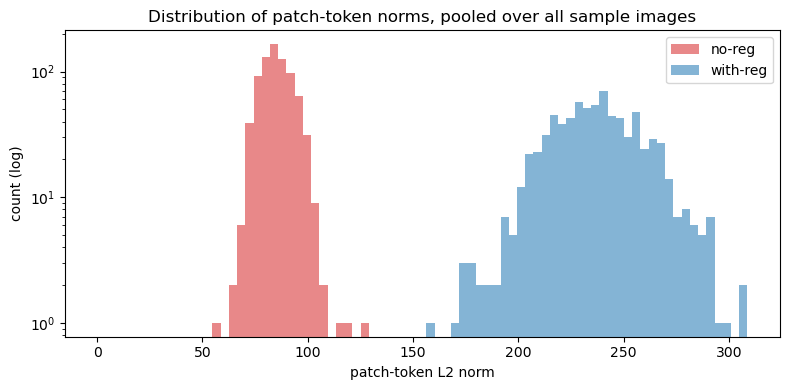

In [10]:
all_plain, all_reg = [], []
for name, img in images:
    all_plain.append(get_patch_tokens(model_plain, img)[0].norm(dim=-1).numpy())  # [0] = prenorm patches
    all_reg.append(get_patch_tokens(model_reg, img)[0].norm(dim=-1).numpy())
all_plain = np.concatenate(all_plain)
all_reg   = np.concatenate(all_reg)

threshold = 1.5 * np.median(np.concatenate([all_plain, all_reg]))

stats = {
    "no-reg": {
        "mean":           float(all_plain.mean()),
        "median":         float(np.median(all_plain)),
        "max":            float(all_plain.max()),
        "max/mean":       float(all_plain.max() / all_plain.mean()),
        f"%>{threshold:.1f}": 100 * float((all_plain > threshold).mean()),
    },
    "with-reg": {
        "mean":           float(all_reg.mean()),
        "median":         float(np.median(all_reg)),
        "max":            float(all_reg.max()),
        "max/mean":       float(all_reg.max() / all_reg.mean()),
        f"%>{threshold:.1f}": 100 * float((all_reg > threshold).mean()),
    },
}

col_width = 12
keys = list(stats["no-reg"].keys())
header = f"{'metric':<20}" + "".join(f"{k:>{col_width}}" for k in keys)
print(header)
print("-" * len(header))
for name, row in stats.items():
    line = f"{name:<20}" + "".join(f"{row[k]:>{col_width}.2f}" for k in keys)
    print(line)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, max(all_plain.max(), all_reg.max()), 80)
ax.hist(all_plain, bins=bins, alpha=0.55, label="no-reg",   color="tab:red")
ax.hist(all_reg,   bins=bins, alpha=0.55, label="with-reg", color="tab:blue")
ax.set_yscale("log")
ax.set_xlabel("patch-token L2 norm")
ax.set_ylabel("count (log)")
ax.set_title("Distribution of patch-token norms, pooled over all sample images")
ax.legend()
plt.tight_layout()
plt.show()